In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

OUT_DIR = "../outputs"
import os
IMG_DIR = "../Images"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)


In [72]:
df = pd.read_csv("../Dataset/heart.csv")
print("=" * 50)
print("Load dataset")
print("=" * 50)
print(f"Shape: {df.shape}")

Load dataset
Shape: (1025, 14)


In [73]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [75]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [76]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [77]:
df.shape

(1025, 14)

In [78]:
df.size

14350

In [79]:
df.duplicated().sum()

np.int64(723)

In [80]:
print("\n-- Placeholder check --")
print("ca value counts:\n", df["ca"].value_counts().sort_index())
print("\nthal value counts:\n", df["thal"].value_counts().sort_index())


-- Placeholder check --
ca value counts:
 ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

thal value counts:
 thal
0      7
1     64
2    544
3    410
Name: count, dtype: int64


In [81]:
n_ca_placeholder = (df["ca"] == 4).sum()
n_thal_placeholder = (df["thal"] == 0).sum()
print(f"\nRows with ca == 4 (placeholder/missing): {n_ca_placeholder}")
print(f"Rows with thal == 0 (placeholder/missing): {n_thal_placeholder}")


Rows with ca == 4 (placeholder/missing): 18
Rows with thal == 0 (placeholder/missing): 7


In [82]:
df["ca"] = df["ca"].replace(4, np.nan)
df["thal"] = df["thal"].replace(0, np.nan)

In [83]:

for col in ["ca", "thal"]:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed missing '{col}' values with mode = {mode_val}")


Imputed missing 'ca' values with mode = 0.0
Imputed missing 'thal' values with mode = 2.0


In [84]:
df["ca"] = df["ca"].astype(int)
df["thal"] = df["thal"].astype(int)

In [85]:
cat_cols = ["cp", "restecg", "slope", "thal", "sex", "fbs", "exang", "target"]
for col in cat_cols:
    print(f"{col}: unique values = {sorted(df[col].unique())}")

cp: unique values = [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
restecg: unique values = [np.int64(0), np.int64(1), np.int64(2)]
slope: unique values = [np.int64(0), np.int64(1), np.int64(2)]
thal: unique values = [np.int64(1), np.int64(2), np.int64(3)]
sex: unique values = [np.int64(0), np.int64(1)]
fbs: unique values = [np.int64(0), np.int64(1)]
exang: unique values = [np.int64(0), np.int64(1)]
target: unique values = [np.int64(0), np.int64(1)]


In [86]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate rows found: 723
Duplicates removed. New shape: (302, 14)


In [87]:
plausibility_ranges = {
    "age": (0, 120),
    "trestbps": (60, 250),   # resting blood pressure (mm Hg)
    "chol": (100, 600),      # serum cholesterol (mg/dl)
}
for col, (low, high) in plausibility_ranges.items():
    out_of_range = df[(df[col] < low) | (df[col] > high)]
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, "
          f"out-of-range rows={len(out_of_range)}")

age: min=29, max=77, out-of-range rows=0
trestbps: min=94, max=200, out-of-range rows=0
chol: min=126, max=564, out-of-range rows=0


In [88]:
zero_bp = (df["trestbps"] == 0).sum()
zero_chol = (df["chol"] == 0).sum()
print(f"trestbps == 0 (implausible): {zero_bp}")
print(f"chol == 0 (implausible): {zero_chol}")

print(f"\nFinal cleaned dataset shape: {df.shape}")
df.to_csv(os.path.join(OUT_DIR, "heart_cleaned.csv"), index=False)
print(f"Cleaned dataset saved to {OUT_DIR}/heart_cleaned.csv")

trestbps == 0 (implausible): 0
chol == 0 (implausible): 0

Final cleaned dataset shape: (302, 14)
Cleaned dataset saved to ../outputs/heart_cleaned.csv


C:\Users\user\AppData\Local\Temp\ipykernel_23064\3068222833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sex_rate, x="sex", y="target", ax=axes[0], palette="Set2")
C:\Users\user\AppData\Local\Temp\ipykernel_23064\3068222833.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cp_rate, x="cp_label", y="target", ax=axes[1], palette="Set3")


Saved figure to ../Images\01_disease_rate_by_sex_and_cp.png


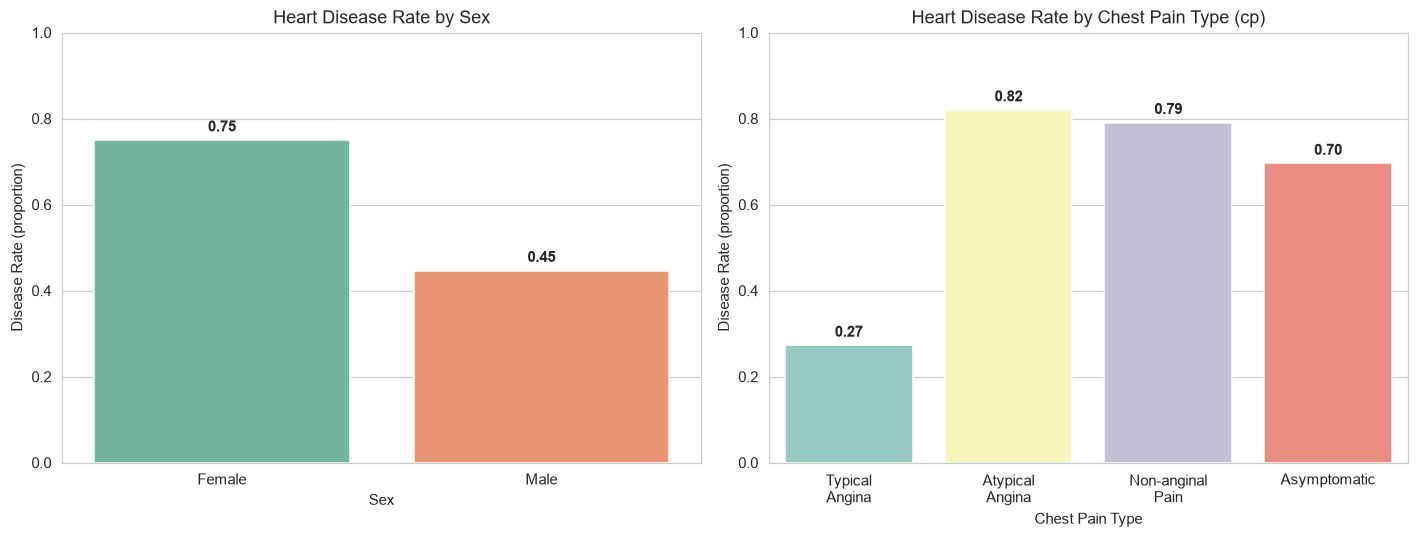

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sex_rate = df.groupby("sex")["target"].mean().reset_index()
sex_rate["sex"] = sex_rate["sex"].map({0: "Female", 1: "Male"})
sns.barplot(data=sex_rate, x="sex", y="target", ax=axes[0], palette="Set2")
axes[0].set_title("Heart Disease Rate by Sex")
axes[0].set_ylabel("Disease Rate (proportion)")
axes[0].set_xlabel("Sex")
axes[0].set_ylim(0, 1)
for i, v in enumerate(sex_rate["target"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")




cp_rate = df.groupby("cp")["target"].mean().reset_index()
cp_labels = {0: "Typical\nAngina", 1: "Atypical\nAngina",
             2: "Non-anginal\nPain", 3: "Asymptomatic"}
cp_rate["cp_label"] = cp_rate["cp"].map(cp_labels)
sns.barplot(data=cp_rate, x="cp_label", y="target", ax=axes[1], palette="Set3")
axes[1].set_title("Heart Disease Rate by Chest Pain Type (cp)")
axes[1].set_ylabel("Disease Rate (proportion)")
axes[1].set_xlabel("Chest Pain Type")
axes[1].set_ylim(0, 1)
for i, v in enumerate(cp_rate["target"]):
    axes[1].text(i, v + 0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout()




# Save the figure to the outputs folder (high-resolution)
save_path = os.path.join(IMG_DIR, "01_disease_rate_by_sex_and_cp.png")
plt.savefig(save_path, bbox_inches="tight", dpi=150)
print(f"Saved figure to {save_path}")

# Display the figure in the notebook/interactive window
plt.show()

# Close the figure to free memory
plt.close()


Saved: ../Images\02_thalach_distribution_by_target.png


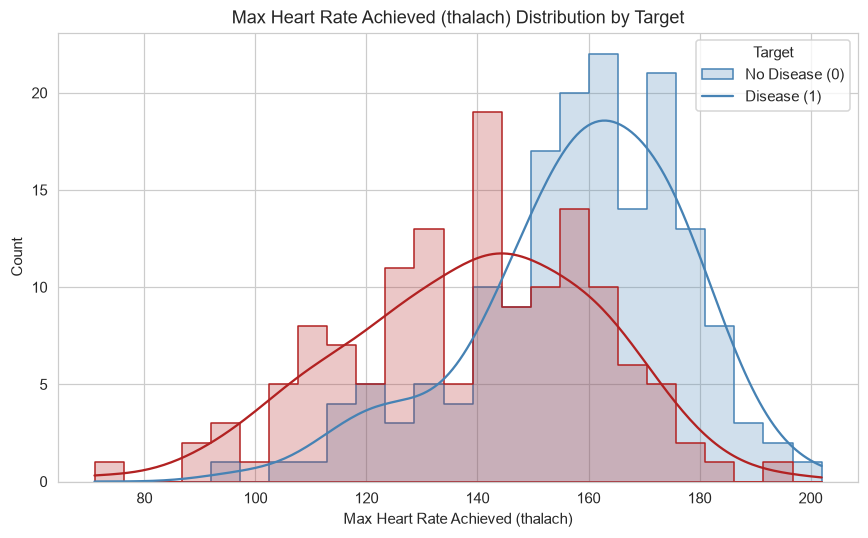

In [90]:
plt.figure(figsize=(8, 5))
ax = sns.histplot(
    data=df, x="thalach", hue="target", kde=True, element="step",
    palette={0: "firebrick", 1: "steelblue"}, bins=25
)

plt.title("Max Heart Rate Achieved (thalach) Distribution by Target")
plt.xlabel("Max Heart Rate Achieved (thalach)")
plt.ylabel("Count")

# seaborn orders hue categories 0 then 1 -> label accordingly
plt.legend(title="Target", labels=["No Disease (0)", "Disease (1)"])

plt.tight_layout()
save_path = os.path.join(IMG_DIR, "02_thalach_distribution_by_target.png")
plt.savefig(save_path, bbox_inches="tight", dpi=150)
print("Saved:", save_path)

plt.show()
plt.close()

Saved: 03_correlation_heatmap.png


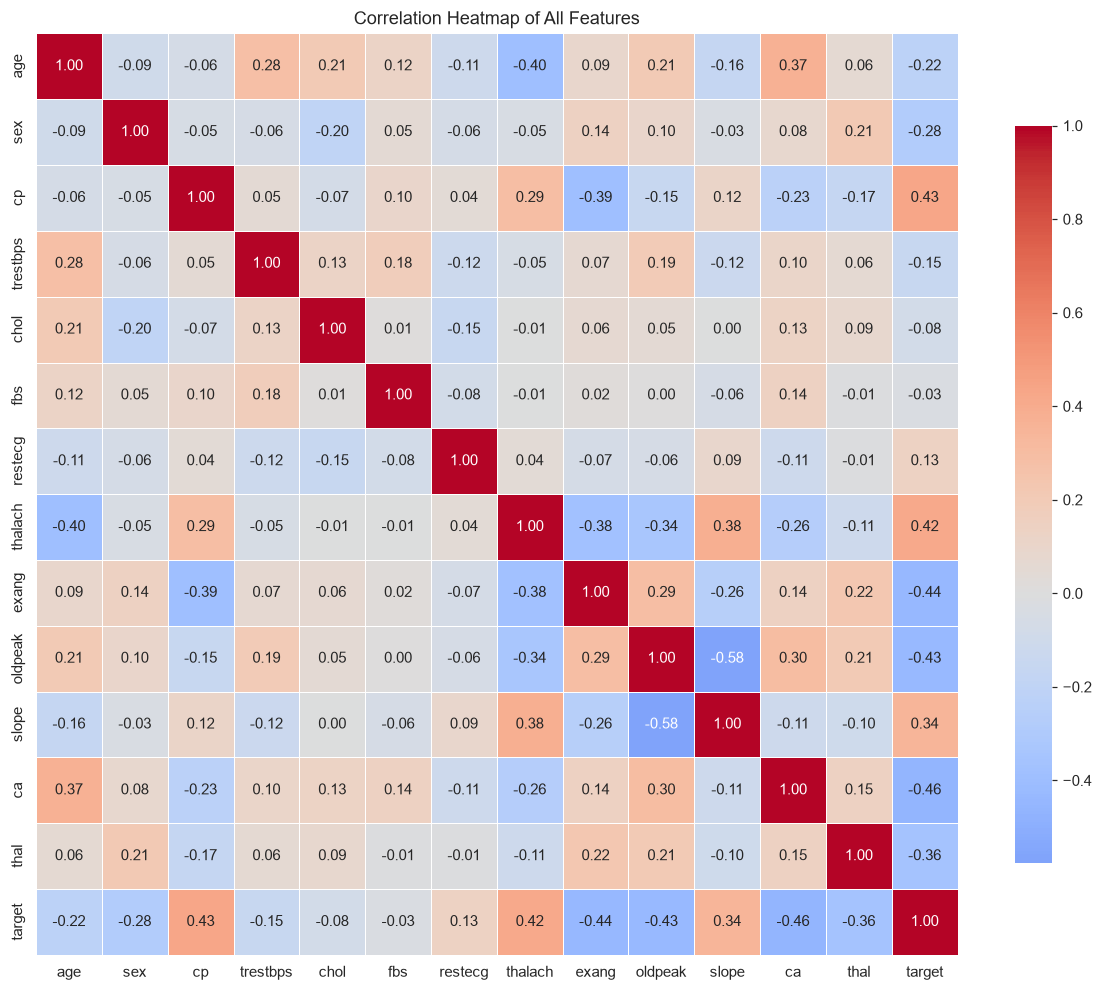

In [91]:
plt.figure(figsize=(11, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "03_correlation_heatmap.png"))
print("Saved: 03_correlation_heatmap.png")
plt.show()
plt.close()

C:\Users\user\AppData\Local\Temp\ipykernel_23064\131042994.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target", y="oldpeak", ax=axes[0], palette="Set1")
C:\Users\user\AppData\Local\Temp\ipykernel_23064\131042994.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="target", y="oldpeak", ax=axes[1], palette="Set1")


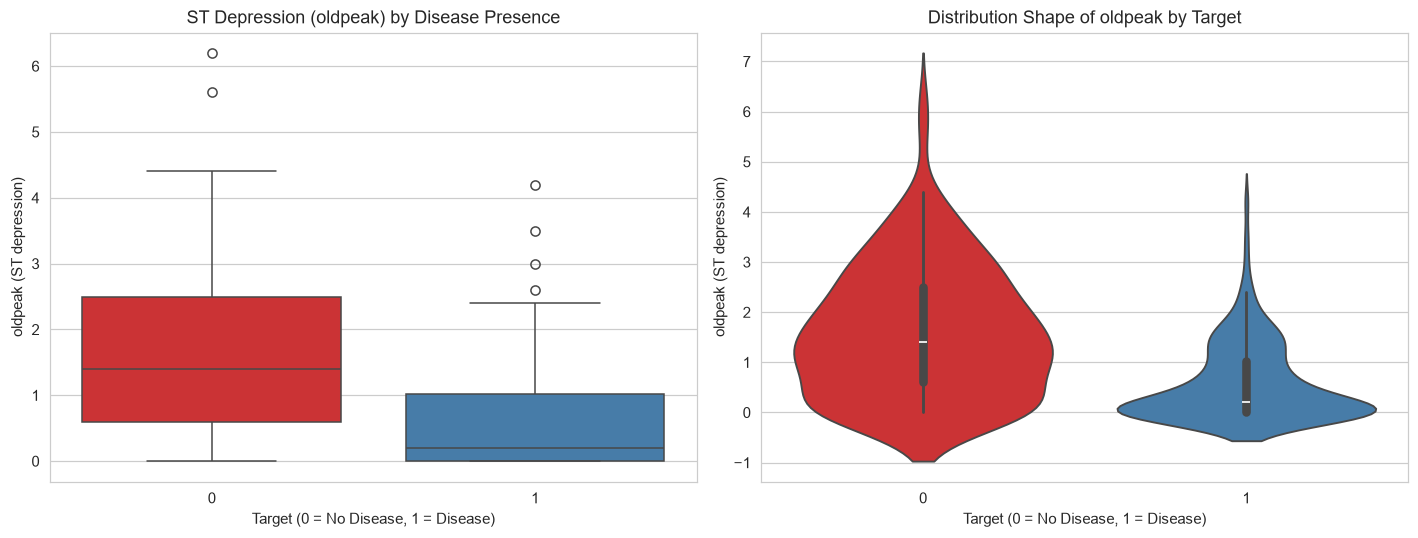

Saved: 04_oldpeak_vs_target.png

oldpeak mean by target group:
            mean  median       std
target                            
0       1.585507     1.4  1.300340
1       0.586585     0.2  0.781734


In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="target", y="oldpeak", ax=axes[0], palette="Set1")
axes[0].set_title("ST Depression (oldpeak) by Disease Presence")
axes[0].set_xlabel("Target (0 = No Disease, 1 = Disease)")
axes[0].set_ylabel("oldpeak (ST depression)")

sns.violinplot(data=df, x="target", y="oldpeak", ax=axes[1], palette="Set1")
axes[1].set_title("Distribution Shape of oldpeak by Target")
axes[1].set_xlabel("Target (0 = No Disease, 1 = Disease)")
axes[1].set_ylabel("oldpeak (ST depression)")

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "04_oldpeak_vs_target.png"))
plt.show()
plt.close()
print("Saved: 04_oldpeak_vs_target.png")

print("\noldpeak mean by target group:")
print(df.groupby("target")["oldpeak"].agg(["mean", "median", "std"]))

## Feature engineering
One-hot encode categorical-coded columns, optional age-decade binning, scale continuous features with StandardScaler, and save outputs.

In [93]:
# Step 1: One-hot encode categorical-coded columns and optional age-decade binning
# Run this cell after cleaning/EDA cells have been executed

# work on a copy so original cleaned df remains
df_fe = df.copy()

# One-hot encode categorical-coded columns
cat_cols = ['cp', 'restecg', 'slope', 'thal']
print('One-hot encoding columns:', cat_cols)
df_fe = pd.get_dummies(df_fe, columns=cat_cols, prefix=cat_cols, drop_first=False)

# Optional: age decade bins
if 'age' in df_fe.columns:
    df_fe['age_decade'] = (df_fe['age'] // 10) * 10
    df_fe['age_decade'] = df_fe['age_decade'].astype(int)
    df_fe = pd.get_dummies(df_fe, columns=['age_decade'], prefix='age_decade', drop_first=False)

print('After one-hot & age binning, shape:', df_fe.shape)
print('Sample columns:', list(df_fe.columns)[:20])

One-hot encoding columns: ['cp', 'restecg', 'slope', 'thal']
After one-hot & age binning, shape: (302, 29)
Sample columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_0', 'slope_1', 'slope_2']


In [94]:
# Step 2: Scale continuous features with StandardScaler and save the scaler
# Define continuous columns to scale
cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cont_cols = [c for c in cont_cols if c in df_fe.columns]
print('Scaling columns:', cont_cols)

from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
if cont_cols:
    df_fe[cont_cols] = scaler.fit_transform(df_fe[cont_cols])
    scaler_path = os.path.join(OUT_DIR, 'standard_scaler.joblib')
    joblib.dump(scaler, scaler_path)
    print('Saved scaler to', scaler_path)
else:
    print('No continuous columns to scale found in df_fe')

Scaling columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Saved scaler to ../outputs\standard_scaler.joblib


In [95]:
# Step 3: Split features and target and save to outputs
if 'target' not in df_fe.columns:
    raise KeyError("'target' column not found in df_fe; ensure cleaning and EDA steps ran")

X = df_fe.drop(columns=['target'])
y = df_fe['target']

X_path = os.path.join(OUT_DIR, 'X_features.csv')
y_path = os.path.join(OUT_DIR, 'y_target.csv')
df_path = os.path.join(OUT_DIR, 'heart_features.csv')

X.to_csv(X_path, index=False)
y.to_csv(y_path, index=False)
df_fe.to_csv(df_path, index=False)

print('Saved:')
print(' -', X_path)
print(' -', y_path)
print(' -', df_path)

Saved:
 - ../outputs\X_features.csv
 - ../outputs\y_target.csv
 - ../outputs\heart_features.csv


In [96]:
# Verification: confirm saved scaler and feature files, and show basic stats
import os
import joblib
import pandas as pd

scaler_path = os.path.join(OUT_DIR, 'standard_scaler.joblib')
print('Scaler path:', scaler_path)
print('Scaler exists:', os.path.exists(scaler_path))
if os.path.exists(scaler_path):
    try:
        scaler = joblib.load(scaler_path)
        print('Loaded scaler:')
        print(' - mean_ length:', getattr(scaler, 'mean_', None).shape if getattr(scaler, 'mean_', None) is not None else None)
    except Exception as e:
        print('Failed to load scaler:', e)

files = ['X_features.csv', 'y_target.csv', 'heart_features.csv']
for f in files:
    p = os.path.join(OUT_DIR, f)
    print(f, 'exists:', os.path.exists(p))
    if os.path.exists(p):
        try:
            tmp = pd.read_csv(p)
            print(' - shape:', tmp.shape)
            print(' - columns (first 12):', list(tmp.columns)[:12])
            print(' - sample means for numeric cols:')
            print(tmp.select_dtypes(include='number').iloc[:,:5].mean())
        except Exception as e:
            print(' - failed to read', f, e)
print('Verification complete.')

Scaler path: ../outputs\standard_scaler.joblib
Scaler exists: True
Loaded scaler:
 - mean_ length: (5,)
X_features.csv exists: True
 - shape: (302, 28)
 - columns (first 12): ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_0', 'cp_1', 'cp_2']
 - sample means for numeric cols:
age        -2.646889e-16
sex         6.821192e-01
trestbps   -6.617223e-16
chol        0.000000e+00
fbs         1.490066e-01
dtype: float64
y_target.csv exists: True
 - shape: (302, 1)
 - columns (first 12): ['target']
 - sample means for numeric cols:
target    0.543046
dtype: float64
heart_features.csv exists: True
 - shape: (302, 29)
 - columns (first 12): ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'target', 'cp_0', 'cp_1']
 - sample means for numeric cols:
age        -2.646889e-16
sex         6.821192e-01
trestbps   -6.617223e-16
chol        0.000000e+00
fbs         1.490066e-01
dtype: float64
Verification complete.


## Model Building

This section follows these steps:

1. Prepare features `X` and target `y` (from the saved feature CSVs).
2. Split data into training and test sets (80/20) stratified by `target`.
3. Train `LogisticRegression` on scaled features.
4. Generate predictions and predicted probabilities on the test set.
5. Save the trained model and predictions to the `outputs/` folder.

Run each cell in order.


In [97]:
# Model Step 1: Load saved features and prepare X, y
import pandas as pd
import os

X = pd.read_csv(os.path.join(OUT_DIR, 'X_features.csv'))
y = pd.read_csv(os.path.join(OUT_DIR, 'y_target.csv'))
# if y is a single-column dataframe, convert to Series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:,0]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target distribution:\n', y.value_counts(normalize=True))

X shape: (302, 28)
y shape: (302,)
Target distribution:
 target
1    0.543046
0    0.456954
Name: proportion, dtype: float64


In [98]:
# Model Step 2: Train/test split (80/20 stratified)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape :', X_test.shape, y_test.shape)

Train shape: (241, 28) (241,)
Test shape : (61, 28) (61,)


In [99]:
# Model Step 3: Train LogisticRegression on scaled features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Accuracy on test set:', accuracy_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred))

# update todo status


Accuracy on test set: 0.8360655737704918

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [100]:
# Model Step 4: Predictions, probabilities, and ROC AUC
import numpy as np

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print('Test accuracy:', accuracy_score(y_test, y_pred))
try:
    auc = roc_auc_score(y_test, y_proba)
    print('ROC AUC:', auc)
except Exception as e:
    print('ROC AUC compute failed:', e)

# Save predictions alongside true labels
pred_df = X_test.copy()
pred_df['y_true'] = y_test.values
pred_df['y_pred'] = y_pred
pred_df['y_proba'] = y_proba
pred_path = os.path.join(OUT_DIR, 'predictions.csv')
pred_df.to_csv(pred_path, index=False)
print('Saved predictions to', pred_path)


Test accuracy: 0.8360655737704918
ROC AUC: 0.9025974025974026
Saved predictions to ../outputs\predictions.csv


In [101]:
# Model Step 5: Save trained model
import joblib
model_path = os.path.join(OUT_DIR, 'logistic_model.joblib')
joblib.dump(model, model_path)
print('Saved model to', model_path)


Saved model to ../outputs\logistic_model.joblib


## Evaluation

This section computes evaluation metrics, plots a confusion matrix and ROC curve (displayed and saved), and lists the strongest coefficients.

Run each cell in order to see plots and saved artifacts in `outputs/`.

In [102]:
# Eval Step 1: Compute classification metrics
import os
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score

# Load model if not in memory
try:
    model
except NameError:
    model = joblib.load(os.path.join(OUT_DIR, 'logistic_model.joblib'))

# Load test data if not in memory
try:
    X_test, y_test
except NameError:
    X = pd.read_csv(os.path.join(OUT_DIR, 'X_features.csv'))
    y = pd.read_csv(os.path.join(OUT_DIR, 'y_target.csv')).iloc[:,0]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Predictions
y_pred = model.predict(X_test)
if hasattr(model, 'predict_proba'):
    y_proba = model.predict_proba(X_test)[:, 1]
else:
    y_proba = None

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

print('Accuracy:', acc)
print('Precision:', prec)
print('Recall:', rec)
print('F1-score:', f1)
print('ROC-AUC:', auc)

print('\nClassification report:\n')
print(classification_report(y_test, y_pred))

# Save numeric metrics
metrics_path = os.path.join(OUT_DIR, 'metrics.txt')
with open(metrics_path, 'w') as f:
    f.write(f'Accuracy: {acc}\n')
    f.write(f'Precision: {prec}\n')
    f.write(f'Recall: {rec}\n')
    f.write(f'F1: {f1}\n')
    f.write(f'ROC-AUC: {auc}\n')
print('Saved metrics to', metrics_path)

Accuracy: 0.8360655737704918
Precision: 0.8484848484848485
Recall: 0.8484848484848485
F1-score: 0.8484848484848485
ROC-AUC: 0.9025974025974026

Classification report:

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61

Saved metrics to ../outputs\metrics.txt


Saved confusion matrix to ../Images\confusion_matrix.png


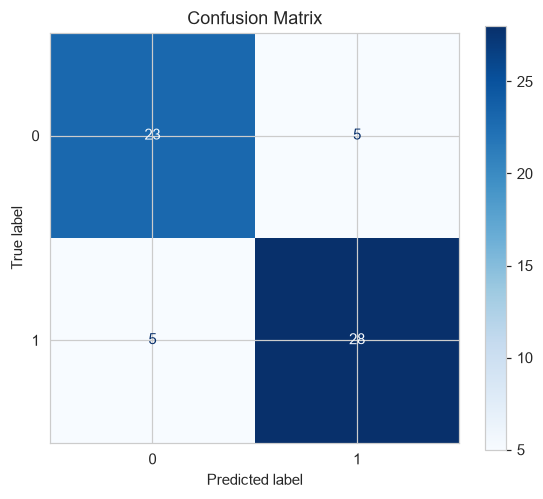

Saved ROC curve to ../Images\roc_curve.png


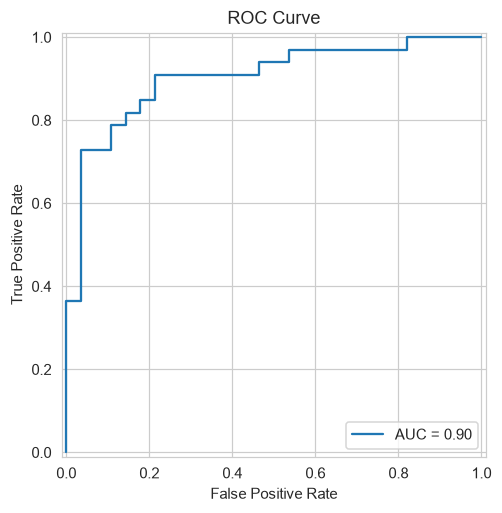

In [103]:
# Eval Step 2: Confusion matrix and ROC curve (display & save)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix')
cm_path = os.path.join(IMG_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, bbox_inches='tight', dpi=150)
print('Saved confusion matrix to', cm_path)
plt.show()
plt.close()

# ROC curve
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fig, ax = plt.subplots(figsize=(6,5))
    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc).plot(ax=ax)
    plt.title('ROC Curve')
    roc_path = os.path.join(IMG_DIR, 'roc_curve.png')
    plt.savefig(roc_path, bbox_inches='tight', dpi=150)
    print('Saved ROC curve to', roc_path)
    plt.show()
    plt.close()
else:
    print('No probability predictions available; ROC curve skipped')

In [104]:
# Eval Step 3: Print sorted coefficients and save top features
import pandas as pd
import numpy as np

# Ensure model and X_test exist
try:
    coef = model.coef_[0]
    feature_names = X_test.columns
except Exception:
    model = joblib.load(os.path.join(OUT_DIR, 'logistic_model.joblib'))
    X_test = pd.read_csv(os.path.join(OUT_DIR, 'X_features.csv'))
    coef = model.coef_[0]
    feature_names = X_test.columns

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)
print('Top 15 features by absolute coefficient:')
print(coef_df.head(15))

# Save coefficients
coef_path = os.path.join(OUT_DIR, 'coefficients.csv')
coef_df.to_csv(coef_path, index=False)
print('Saved coefficients to', coef_path)

Top 15 features by absolute coefficient:
          feature      coef  abs_coef
0             sex -1.337854  1.337854
1              ca -1.199149  1.199149
2            cp_0 -1.130197  1.130197
3           exang -0.885689  0.885689
4          thal_3 -0.791671  0.791671
5         thalach  0.728877  0.728877
6            cp_2  0.706110  0.706110
7            cp_3  0.693880  0.693880
8   age_decade_70  0.571763  0.571763
9         slope_1 -0.431521  0.431521
10        slope_2  0.429407  0.429407
11         thal_1  0.408671  0.408671
12         thal_2  0.386067  0.386067
13       trestbps -0.342149  0.342149
14           cp_1 -0.266725  0.266725
Saved coefficients to ../outputs\coefficients.csv


## Discussion: Why recall matters for medical screening

- **Recall (sensitivity)** measures the proportion of actual positives correctly identified. In medical screening, false negatives (missed disease) can lead to delayed treatment and worse outcomes, so high recall reduces patient risk.
- **Precision vs Recall trade-off:** In screening, prioritize recall; downstream confirmatory tests can handle false positives.
- When reporting results, include recall and discuss clinical implications.

_Suggestion_: If you need higher recall, consider adjusting decision threshold, using class weights, or optimizing recall during model selection.